In [1]:
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
import random

In [2]:
models_to_plot = ["RNN-256", "GRU-256", "LSTM-256", "TRF-256"]
model_markers = {'RNN-256': 'o', 'GRU-256': 's', 'LSTM-256': 'D', 'TRF-256': '^'}
categories = ['Color', 'Conj']

In [3]:
plt.rcParams["font.family"] = "Serif"
sns.set_context("paper", font_scale=1.1)
sns.set_style("ticks")

combinations = [f"{m}-{c}" for m in models_to_plot for c in categories]

In [4]:
human_plot_data = {
    'Color': [[2, 4, 6], [0.985, 0.945, 0.84]], 
    'Orientation': [[2, 4, 6], [0.955, 0.90, 0.81]], 
    'Size': [[2, 4, 6], [0.975, 0.93, 0.82]], 
    'Gap': [[2, 4, 6], [0.945, 0.89, 0.80]], 
    'Conj': [[2, 4, 6], [0.965, 0.92, 0.83]]
}

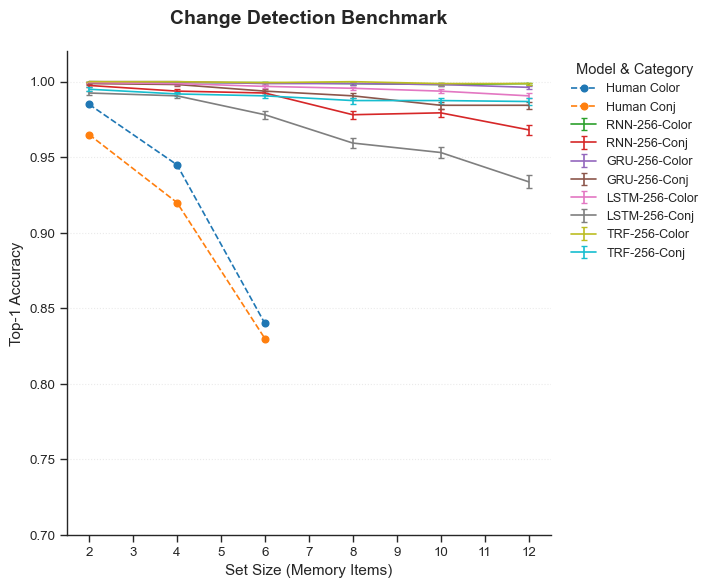

In [5]:
def get_val(key, tag):
    try: return key.split(tag)[1].split("_")[0]
    except: return None

plot_data = {} 

for m_name in models_to_plot:
    try:
        paths = [f"WM_Bench/{m_name}/output/test_acc_results.json", "test_acc_results.json"]
        results = None
        for p in paths:
            try:
                with open(p, "r") as f:
                    results = json.load(f)
                    break
            except FileNotFoundError: continue
        
        if results is None: continue

        m_agg = {cat: {} for cat in categories}
        for key, val in results.items():
            if "CD_" in key and "_set_size_" in key:
                found_cat = next((c for c in categories if c in key or (c == 'Conj' and 'Conj' in key)), None)
                ss_str = get_val(key, "_set_size_")
                
                if found_cat and ss_str:
                    ss = int(ss_str)
                    if ss not in m_agg[found_cat]: m_agg[found_cat][ss] = [0, 0]
                    m_agg[found_cat][ss][0] += val[0]
                    m_agg[found_cat][ss][1] += val[1]

        model_final = {}
        for cat in categories:
            if m_agg[cat]:
                ss_sorted = sorted(m_agg[cat].keys())
                accs, sems = [], []
                for s in ss_sorted:
                    correct, total = m_agg[cat][s]
                    p = correct / total
                    accs.append(p)
                    sems.append(np.sqrt((p * (1 - p)) / total))
                model_final[cat] = (ss_sorted, accs, sems)
        plot_data[m_name] = model_final
    except Exception as e: print(f"Error processing {m_name}: {e}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_box_aspect(1)

# Human Baseline 
for cat in categories:
    x_h, y_h = human_plot_data[cat]
    ax.plot(x_h, y_h, '--o', label=f'Human {cat}', zorder=1)

# Plot Architectures 
for m_name in models_to_plot:
    if m_name in plot_data:
        marker = model_markers.get(m_name, 'o')
        for cat in categories:
            if cat in plot_data[m_name]:
                x, y, yerr = plot_data[m_name][cat]
                combo_name = f"{m_name}-{cat}"
                
                ax.errorbar(x, y, yerr=yerr, label=combo_name, 
                            markersize=5, linewidth=1.2, capsize=2, zorder=2)

ax.set_title("Change Detection Benchmark", fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel("Set Size (Memory Items)", fontsize=11)
ax.set_ylabel("Top-1 Accuracy", fontsize=11)

ax.set_xticks(range(2, 13)) 
ax.set_xlim([1.5, 12.5])
ax.set_ylim([0.7, 1.02]) 

ax.grid(axis='y', linestyle=':', alpha=0.4)
sns.despine(ax=ax)

ax.legend(title="Model & Category", frameon=False, loc='upper left', 
          bbox_to_anchor=(1.02, 1), fontsize=9)

plt.tight_layout()
plt.show()